In [5]:
from pathlib import Path

cwd = Path().resolve().parent.parent.parent

In [14]:
import pandas as pd 
import base64
import io
import json
import sqlite3
from datetime import datetime
from pathlib import Path
from typing import Any

import matplotlib
matplotlib.use('Agg')  # Non-interactive backend for server use
import matplotlib.pyplot as plt
import numpy as np
# from mcp.server.fastmcp import FastMCP
from scipy import stats
# Store loaded datasets in memory for efficient re-use
_datasets: dict[str, pd.DataFrame] = {}
cwd = Path().resolve()
_PROJECT_ROOT = cwd.parent.parent.parent 

In [15]:

def _resolve_path(file_path: str) -> Path:
    """
    Resolve file path relative to project root if it's a relative path.
    
    Args:
        file_path: Absolute or relative file path
    
    Returns:
        Resolved absolute Path
    """
    path = Path(file_path)
    
    # If absolute path, use as-is
    if path.is_absolute():
        return path
    
    # Otherwise, resolve relative to project root
    resolved = _PROJECT_ROOT / path
    return resolved.resolve()

In [9]:
# An Internal Helper (Hidden from the LLM/Client) : function name with "_" at start
def _load_data(file_path: str) -> pd.DataFrame:
    """Load data from CSV or SQLite file."""
    path = _resolve_path(file_path)
    
    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {file_path}\n"
            f"Resolved to: {path}\n"
            f"Project root: {_PROJECT_ROOT}\n"
            f"Current working directory: {Path.cwd()}"
        )
    
    suffix = path.suffix.lower()
    
    if suffix == ".csv":
        return pd.read_csv(str(path))
    elif suffix in (".db", ".sqlite", ".sqlite3"):
        # For SQLite, list tables or load first table
        conn = sqlite3.connect(str(path))
        tables = pd.read_sql_query(
            "SELECT name FROM sqlite_master WHERE type='table'", conn
        )
        if tables.empty:
            conn.close()
            raise ValueError(f"No tables found in SQLite database: {file_path}")
        first_table = tables.iloc[0]["name"]
        df = pd.read_sql_query(f"SELECT * FROM {first_table}", conn)
        conn.close()
        return df
    else:
        raise ValueError(f"Unsupported file format: {suffix}. Use .csv or .db/.sqlite")


def _get_numeric_columns(df: pd.DataFrame) -> list[str]:
    """Get list of numeric column names."""
    return df.select_dtypes(include=[np.number]).columns.tolist()

def describe_dataset(file_path: str, include_all: bool = False) -> dict[str, Any]:
    """
    Generate comprehensive statistics for a tabular dataset.
    
    Args:
        file_path: Path to CSV or SQLite file
        include_all: If True, include statistics for all columns (not just numeric)
    
    Returns:
        Dictionary containing:
        - shape: (rows, columns)
        - columns: List of column names with their types
        - numeric_stats: Descriptive statistics for numeric columns
        - missing_values: Count of missing values per column
        - sample: First 5 rows as preview
    """
    df = _load_data(file_path)
    
    # Basic info
    result = {
        "shape": {"rows": len(df), "columns": len(df.columns)},
        "columns": {
            col: str(df[col].dtype) for col in df.columns
        },
        "missing_values": df.isnull().sum().to_dict(),
    }
    
    # Numeric statistics
    numeric_cols = _get_numeric_columns(df)
    if numeric_cols:
        stats_df = df[numeric_cols].describe()
        # Add additional stats
        stats_df.loc["median"] = df[numeric_cols].median()
        stats_df.loc["skew"] = df[numeric_cols].skew()
        stats_df.loc["kurtosis"] = df[numeric_cols].kurtosis()
        result["numeric_stats"] = stats_df.to_dict()
    
    # Categorical columns info
    cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
    if cat_cols:
        result["categorical_columns"] = {
            col: {
                "unique_values": df[col].nunique(),
                "top_values": df[col].value_counts().head(5).to_dict()
            }
            for col in cat_cols
        }
    
    # Sample data
    result["sample"] = df.head(5).to_dict(orient="records")
    
    return result



In [18]:
file_name = "sample_sales.csv"
file_path = f"{_PROJECT_ROOT}/mcps/data/{file_name}"
describe_dataset(file_path)

/var/folders/mh/p31c9s4j7x96gcg6jjhwgmd00000gn/T/ipykernel_88073/1494764829.py:77: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()


{'shape': {'rows': 30, 'columns': 8},
 'columns': {'date': 'str',
  'product': 'str',
  'category': 'str',
  'quantity': 'int64',
  'unit_price': 'float64',
  'total_sales': 'float64',
  'region': 'str',
  'customer_age': 'int64'},
 'missing_values': {'date': 0,
  'product': 0,
  'category': 0,
  'quantity': 0,
  'unit_price': 0,
  'total_sales': 0,
  'region': 0,
  'customer_age': 0},
 'numeric_stats': {'quantity': {'count': 30.0,
   'mean': 58.93333333333333,
   'std': 165.84141434709147,
   'min': 1.0,
   '25%': 7.25,
   '50%': 15.5,
   '75%': 27.25,
   'max': 800.0,
   'median': 15.5,
   'skew': 3.9706986475352233,
   'kurtosis': 15.705119519473795},
  'unit_price': {'count': 30.0,
   'mean': 55.15666666666667,
   'std': 45.57077355387827,
   'min': 14.99,
   '25%': 19.99,
   '50%': 29.99,
   '75%': 89.99,
   'max': 149.99,
   'median': 29.99,
   'skew': 1.165338830499183,
   'kurtosis': 0.14419773111684542},
  'total_sales': {'count': 30.0,
   'mean': 4719.077333333334,
   'std': 

In [20]:
def create_pivot_table(
    file_path: str,
    index: list[str],
    columns: list[str] | None = None,
    values: str | None = None,
    aggfunc: str = "mean",
    fill_value: float | None = None,
) -> dict[str, Any]:
    """
    Create a pivot table from tabular data - the most common business analysis operation.
    
    Args:
        file_path: Path to CSV or SQLite file
        index: Column(s) to use as row labels (grouping)
        columns: Column(s) to use as column headers (optional)
        values: Column to aggregate (default: first numeric column)
        aggfunc: Aggregation function - 'sum', 'mean', 'count', 'min', 'max', 'median', 'std'
        fill_value: Value to replace missing entries (default: None = show as null)
    
    Returns:
        Dictionary containing the pivot table data and metadata
    
    Example:
        create_pivot_table(
            file_path="data/sales.csv",
            index=["region"],
            columns=["category"],
            values="revenue",
            aggfunc="sum"
        )
    """
    df = _load_data(file_path)
    
    # Validate index columns
    invalid = [c for c in index if c not in df.columns]
    if invalid:
        raise ValueError(f"Index columns not found: {invalid}. Available: {df.columns.tolist()}")
    
    # Validate columns if provided
    if columns:
        invalid = [c for c in columns if c not in df.columns]
        if invalid:
            raise ValueError(f"Column headers not found: {invalid}")
    
    # Default to first numeric column if values not specified
    if values is None:
        numeric_cols = _get_numeric_columns(df)
        if not numeric_cols:
            raise ValueError("No numeric columns found for aggregation")
        values = numeric_cols[0]
    elif values not in df.columns:
        raise ValueError(f"Values column '{values}' not found")
    
    # Map aggfunc string to function
    agg_map = {
        "sum": "sum",
        "mean": "mean",
        "count": "count",
        "min": "min",
        "max": "max",
        "median": "median",
        "std": "std",
    }
    if aggfunc not in agg_map:
        raise ValueError(f"Unknown aggfunc: {aggfunc}. Use: {list(agg_map.keys())}")
    
    # Create pivot table
    pivot = pd.pivot_table(
        df,
        values=values,
        index=index,
        columns=columns,
        aggfunc=agg_map[aggfunc],
        fill_value=fill_value,
    )
    
    # Reset index for cleaner output
    pivot_reset = pivot.reset_index()
    
    return {
        "index": index,
        "columns": columns,
        "values": values,
        "aggfunc": aggfunc,
        "shape": {"rows": len(pivot), "columns": len(pivot.columns)},
        "pivot_table": pivot_reset.to_dict(orient="records"),
        "summary": {
            "total": float(pivot.values.sum()) if np.issubdtype(pivot.values.dtype, np.number) else None,
            "grand_mean": float(pivot.values.mean()) if np.issubdtype(pivot.values.dtype, np.number) else None,
        }
    }

create_pivot_table(file_path, index=["region"], columns=["category"], values="total_sales", aggfunc="sum")

{'index': ['region'],
 'columns': ['category'],
 'values': 'total_sales',
 'aggfunc': 'sum',
 'shape': {'rows': 4, 'columns': 2},
 'pivot_table': [{'region': 'East',
   'Electronics': 1154.3899999999999,
   'Home': 2338.9700000000003},
  {'region': 'North', 'Electronics': 9614.36, 'Home': 1469.65},
  {'region': 'South', 'Electronics': 2374.07, 'Home': 120921.91},
  {'region': 'West', 'Electronics': 2289.1, 'Home': 1409.87}],
 'summary': {'total': 141572.32, 'grand_mean': 17696.54}}

In [21]:
def analyze_time_series(
    file_path: str,
    date_column: str,
    value_column: str,
    freq: str = "D",
    include_forecast: bool = False,
) -> dict[str, Any]:
    """
    Perform time series analysis including trend detection, seasonality, and statistics.
    
    Args:
        file_path: Path to CSV or SQLite file
        date_column: Name of the date/datetime column
        value_column: Name of the numeric column to analyze
        freq: Frequency for resampling - 'D' (daily), 'W' (weekly), 'M' (monthly), 'Q' (quarterly), 'Y' (yearly)
        include_forecast: If True, include simple moving average forecast
    
    Returns:
        Dictionary containing:
        - trend: Overall trend direction and statistics
        - statistics: Time series statistics
        - moving_averages: 7, 30, 90 period moving averages
        - seasonality: Day of week / month patterns
        - forecast: Simple forecast if requested
    """
    df = _load_data(file_path)
    
    if date_column not in df.columns:
        raise ValueError(f"Date column '{date_column}' not found. Available: {df.columns.tolist()}")
    if value_column not in df.columns:
        raise ValueError(f"Value column '{value_column}' not found")
    
    # Parse dates
    df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
    df = df.dropna(subset=[date_column, value_column])
    df = df.sort_values(date_column)
    
    # Create time series
    ts = df.set_index(date_column)[value_column]
    
    if len(ts) < 3:
        raise ValueError("Need at least 3 data points for time series analysis")
    
    # Basic statistics
    date_range = {
        "start": str(ts.index.min().date()),
        "end": str(ts.index.max().date()),
        "periods": len(ts),
        "span_days": (ts.index.max() - ts.index.min()).days,
    }
    
    # Trend analysis using linear regression
    x = np.arange(len(ts))
    slope, intercept, r_value, p_value, std_err = stats.linregress(x, ts.values)
    
    trend_direction = "increasing" if slope > 0 else "decreasing" if slope < 0 else "flat"
    trend_strength = abs(r_value)
    
    trend = {
        "direction": trend_direction,
        "slope": round(float(slope), 4),
        "r_squared": round(float(r_value ** 2), 4),
        "strength": "strong" if trend_strength > 0.7 else "moderate" if trend_strength > 0.4 else "weak",
        "pct_change_total": round(float((ts.iloc[-1] - ts.iloc[0]) / ts.iloc[0] * 100), 2) if ts.iloc[0] != 0 else None,
    }
    
    # Calculate moving averages
    ma_result = {}
    for window in [7, 30, 90]:
        if len(ts) >= window:
            ma = ts.rolling(window=window).mean()
            ma_result[f"ma_{window}"] = {
                "current": round(float(ma.iloc[-1]), 2) if not pd.isna(ma.iloc[-1]) else None,
                "min": round(float(ma.min()), 2),
                "max": round(float(ma.max()), 2),
            }
    
    # Resample by frequency
    resampled = ts.resample(freq).agg(['mean', 'sum', 'count', 'min', 'max'])
    
    # Seasonality analysis (if enough data)
    seasonality = {}
    if len(df) >= 7:
        df['dow'] = df[date_column].dt.day_name()
        dow_stats = df.groupby('dow')[value_column].mean().reindex([
            'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'
        ])
        seasonality['day_of_week'] = dow_stats.round(2).to_dict()
        
        best_day = dow_stats.idxmax()
        worst_day = dow_stats.idxmin()
        seasonality['insights'] = {
            'best_day': best_day,
            'worst_day': worst_day,
            'variation_pct': round(float((dow_stats.max() - dow_stats.min()) / dow_stats.mean() * 100), 1) if dow_stats.mean() != 0 else 0,
        }
    
    if len(df) >= 30:
        df['month'] = df[date_column].dt.month_name()
        month_stats = df.groupby('month')[value_column].mean()
        seasonality['monthly'] = month_stats.round(2).to_dict()
    
    # Statistics
    statistics = {
        "mean": round(float(ts.mean()), 2),
        "median": round(float(ts.median()), 2),
        "std": round(float(ts.std()), 2),
        "min": round(float(ts.min()), 2),
        "max": round(float(ts.max()), 2),
        "volatility": round(float(ts.std() / ts.mean() * 100), 2) if ts.mean() != 0 else 0,
    }
    
    # Simple forecast using moving average
    forecast = None
    if include_forecast and len(ts) >= 7:
        forecast_window = min(7, len(ts))
        forecast_value = ts.tail(forecast_window).mean()
        forecast = {
            "method": f"{forecast_window}-period moving average",
            "next_period_estimate": round(float(forecast_value), 2),
            "confidence_note": "Simple estimate based on recent average",
        }
    
    # Recent data sample
    recent_data = ts.tail(10).reset_index()
    recent_data.columns = ['date', 'value']
    recent_data['date'] = recent_data['date'].dt.strftime('%Y-%m-%d')
    
    return {
        "date_column": date_column,
        "value_column": value_column,
        "date_range": date_range,
        "trend": trend,
        "statistics": statistics,
        "moving_averages": ma_result,
        "seasonality": seasonality,
        "resampled_by": freq,
        "resampled_periods": len(resampled),
        "forecast": forecast,
        "recent_data": recent_data.to_dict(orient='records'),
    }

analyze_time_series(file_path, date_column="date", value_column="total_sales")

{'date_column': 'date',
 'value_column': 'total_sales',
 'date_range': {'start': '2024-01-05',
  'end': '2024-01-19',
  'periods': 30,
  'span_days': 14},
 'trend': {'direction': 'increasing',
  'slope': 777.9606,
  'r_squared': 0.0986,
  'strength': 'weak',
  'pct_change_total': 26573.78},
 'statistics': {'mean': 4719.08,
  'median': 512.27,
  'std': 21809.39,
  'min': 149.99,
  'max': 119992.0,
  'volatility': 462.15},
 'moving_averages': {'ma_7': {'current': 17600.12,
   'min': 406.3,
   'max': 17600.12},
  'ma_30': {'current': 4719.08, 'min': 4719.08, 'max': 4719.08}},
 'seasonality': {'day_of_week': {'Monday': 528.5,
   'Tuesday': 409.94,
   'Wednesday': 598.55,
   'Thursday': 537.25,
   'Friday': 20458.56,
   'Saturday': 2148.66,
   'Sunday': 482.34},
  'insights': {'best_day': 'Friday',
   'worst_day': 'Tuesday',
   'variation_pct': 557.7},
  'monthly': {'January': 4719.08}},
 'resampled_by': 'D',
 'resampled_periods': 15,
 'forecast': None,
 'recent_data': [{'date': '2024-01-15

In [23]:
def generate_chart(
    file_path: str,
    chart_type: str,
    x_column: str | None = None,
    y_column: str | None = None,
    group_by: str | None = None,
    title: str | None = None,
    output_format: str = "base64",
) -> dict[str, Any]:
    """
    Generate a chart/visualization from tabular data.
    Returns chart as base64-encoded PNG for display.
    
    Args:
        file_path: Path to CSV or SQLite file
        chart_type: Type of chart - 'bar', 'line', 'scatter', 'histogram', 'pie', 'box'
        x_column: Column for X-axis (not needed for histogram/pie)
        y_column: Column for Y-axis values
        group_by: Optional column for grouping/coloring
        title: Chart title (auto-generated if not provided)
        output_format: 'base64' (default) or 'file' (saves to data/charts/)
    
    Returns:
        Dictionary containing chart data as base64 or file path
    """
    df = _load_data(file_path)
    
    valid_types = ['bar', 'line', 'scatter', 'histogram', 'pie', 'box']
    if chart_type not in valid_types:
        raise ValueError(f"Unknown chart_type: {chart_type}. Use: {valid_types}")
    
    # Set up the figure with a clean style
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Generate chart based on type
    if chart_type == 'histogram':
        if y_column is None:
            numeric_cols = _get_numeric_columns(df)
            if not numeric_cols:
                raise ValueError("No numeric columns found for histogram")
            y_column = numeric_cols[0]
        
        ax.hist(df[y_column].dropna(), bins=30, edgecolor='black', alpha=0.7, color='#4C72B0')
        ax.set_xlabel(y_column)
        ax.set_ylabel('Frequency')
        auto_title = f'Distribution of {y_column}'
        
    elif chart_type == 'pie':
        if x_column is None:
            cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
            if not cat_cols:
                raise ValueError("No categorical columns found for pie chart")
            x_column = cat_cols[0]
        
        value_counts = df[x_column].value_counts().head(10)
        colors = plt.cm.Set3(np.linspace(0, 1, len(value_counts)))
        ax.pie(value_counts.values, labels=value_counts.index, autopct='%1.1f%%', colors=colors)
        auto_title = f'Distribution of {x_column}'
        
    elif chart_type == 'box':
        if y_column is None:
            numeric_cols = _get_numeric_columns(df)
            if not numeric_cols:
                raise ValueError("No numeric columns found for box plot")
            y_column = numeric_cols[0]
        
        if group_by and group_by in df.columns:
            groups = df[group_by].unique()[:10]  # Limit to 10 groups
            data = [df[df[group_by] == g][y_column].dropna() for g in groups]
            ax.boxplot(data, labels=groups)
            ax.set_xlabel(group_by)
        else:
            ax.boxplot(df[y_column].dropna())
        ax.set_ylabel(y_column)
        auto_title = f'Box Plot of {y_column}'
        
    elif chart_type in ['bar', 'line', 'scatter']:
        if x_column is None or y_column is None:
            raise ValueError(f"Both x_column and y_column are required for {chart_type} chart")
        
        if x_column not in df.columns:
            raise ValueError(f"x_column '{x_column}' not found")
        if y_column not in df.columns:
            raise ValueError(f"y_column '{y_column}' not found")
        
        if group_by and group_by in df.columns:
            for name, group in df.groupby(group_by):
                if chart_type == 'bar':
                    ax.bar(group[x_column].astype(str), group[y_column], label=str(name), alpha=0.7)
                elif chart_type == 'line':
                    ax.plot(group[x_column], group[y_column], label=str(name), marker='o', markersize=4)
                else:  # scatter
                    ax.scatter(group[x_column], group[y_column], label=str(name), alpha=0.7)
            ax.legend(title=group_by, loc='best')
        else:
            if chart_type == 'bar':
                # For bar charts, aggregate if needed
                if df[x_column].dtype == 'object':
                    agg = df.groupby(x_column)[y_column].mean()
                    ax.bar(agg.index.astype(str), agg.values, color='#4C72B0', alpha=0.7)
                else:
                    ax.bar(df[x_column].astype(str).head(50), df[y_column].head(50), color='#4C72B0', alpha=0.7)
            elif chart_type == 'line':
                ax.plot(df[x_column], df[y_column], marker='o', markersize=4, color='#4C72B0')
            else:  # scatter
                ax.scatter(df[x_column], df[y_column], alpha=0.6, color='#4C72B0')
        
        ax.set_xlabel(x_column)
        ax.set_ylabel(y_column)
        auto_title = f'{y_column} by {x_column}'
        
        # Rotate x labels if needed
        if df[x_column].dtype == 'object' or chart_type == 'bar':
            plt.xticks(rotation=45, ha='right')
    
    # Set title
    ax.set_title(title or auto_title, fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    # Save chart
    if output_format == 'file':
        charts_dir = _PROJECT_ROOT / 'data' / 'charts'
        charts_dir.mkdir(parents=True, exist_ok=True)
        timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
        filename = f'{chart_type}_{timestamp}.png'
        filepath = charts_dir / filename
        plt.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.close()
        
        return {
            "chart_type": chart_type,
            "file_path": str(filepath.relative_to(_PROJECT_ROOT)),
            "absolute_path": str(filepath),
        }
    else:
        # Return as base64
        buffer = io.BytesIO()
        plt.savefig(buffer, format='png', dpi=150, bbox_inches='tight')
        plt.close()
        buffer.seek(0)
        image_base64 = base64.b64encode(buffer.getvalue()).decode('utf-8')
        
        return {
            "chart_type": chart_type,
            "format": "png",
            "encoding": "base64",
            "image_data": image_base64,
            "display_note": "Use this base64 string to display the image",
        }

result = generate_chart(file_path, chart_type='bar', x_column='region', y_column='total_sales')

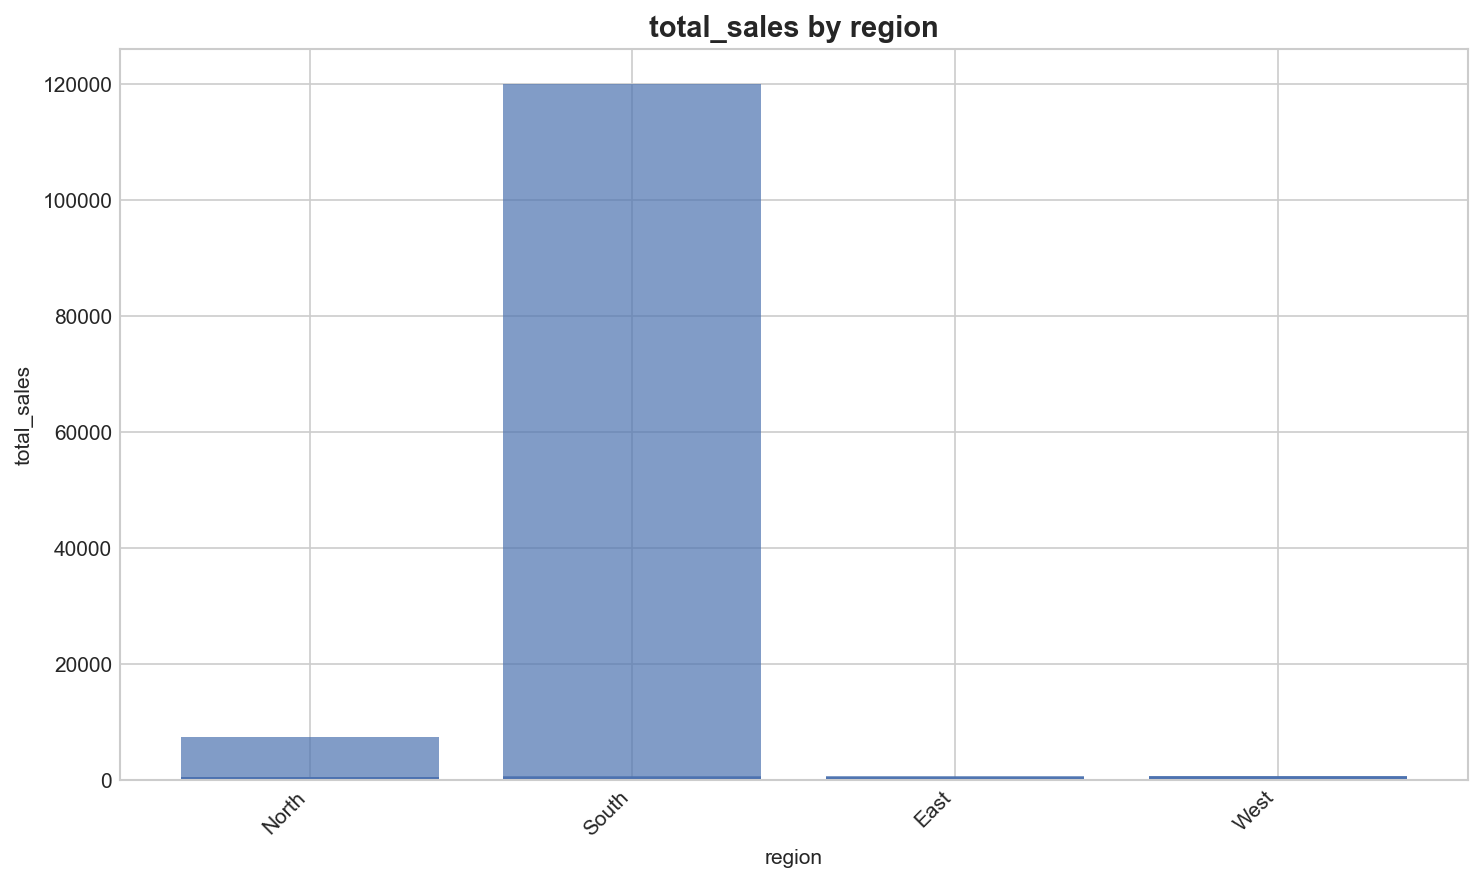

In [24]:
from IPython.display import Image, display

# Assuming 'result' is the dictionary returned by your function
base64_string = result["image_data"]

# Display the image
display(Image(data=base64.b64decode(base64_string)))